In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/credit_card_transactions.csv", nrows=10000)

In [3]:
print(df.shape)

(10000, 24)


In [4]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

In [5]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             10000 non-null  int64  
 1   trans_date_trans_time  10000 non-null  object 
 2   cc_num                 10000 non-null  int64  
 3   merchant               10000 non-null  object 
 4   category               10000 non-null  object 
 5   amt                    10000 non-null  float64
 6   first                  10000 non-null  object 
 7   last                   10000 non-null  object 
 8   gender                 10000 non-null  object 
 9   street                 10000 non-null  object 
 10  city                   10000 non-null  object 
 11  state                  10000 non-null  object 
 12  zip                    10000 non-null  int64  
 13  lat                    10000 non-null  float64
 14  long                   10000 non-null  float64
 15  cit

In [7]:
# Remove unwanted column
df.drop('Unnamed: 0', axis=1, inplace=True)

# Convert dates
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

print("Done")

Done


In [8]:
total_transaction_value = df['amt'].sum()

print("Total Transaction Value:", total_transaction_value)

Total Transaction Value: 684134.86


In [9]:
total_transactions = len(df)

print("Total Transactions:", total_transactions)

Total Transactions: 10000


In [10]:
avg_transaction = df['amt'].mean()

print("Average Transaction Value:", round(avg_transaction, 2))

Average Transaction Value: 68.41


In [11]:
fraud_transactions = df['is_fraud'].sum()

print("Fraud Transactions:", fraud_transactions)

Fraud Transactions: 47


In [12]:
fraud_rate = (df['is_fraud'].sum() / len(df)) * 100

print("Fraud Rate:", round(fraud_rate, 2), "%")

Fraud Rate: 0.47 %


In [13]:
df.groupby('gender')['amt'].sum()

,amt
gender,
F,371762.76
M,312372.10


In [14]:
df.groupby('category')['amt'].sum().sort_values(ascending=False).head(10)

,amt
category,
grocery_pos,116769.38
gas_transport,68274.03
shopping_net,65005.33
shopping_pos,61729.77
home,54575.94
misc_net,47366.59
kids_pets,46627.81
entertainment,43424.92
food_dining,35131.02


In [15]:
df.groupby('category')['is_fraud'].sum().sort_values(ascending=False).head(10)

,is_fraud
category,
grocery_pos,13
shopping_net,12
misc_net,6
shopping_pos,6
gas_transport,5
grocery_net,1
travel,1
misc_pos,1
health_fitness,1


In [16]:
df.groupby('state')['amt'].sum().sort_values(ascending=False).head(10)

,amt
state,
PA,47523.49
TX,45789.65
NY,39411.26
CA,30677.16
MI,28832.87
OH,26349.72
IL,23836.76
MO,21680.76
NC,21378.20


In [17]:
df['age'] = 2026 - df['dob'].dt.year

df['age'].describe()

,age
count,10000.000000
mean,53.337300
std,17.460756
min,21.000000
25%,40.000000
50%,51.000000
75%,64.000000
max,102.000000


In [18]:
bins = [18, 25, 35, 45, 55, 65, 100]

labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['age_group'] = pd.cut(df['age'],
                         bins=bins,
                         labels=labels)

df['age_group'].value_counts()

,count
age_group,
46-55,2363
65+,2314
36-45,2262
56-65,1570
26-35,1357
18-25,133


In [19]:
df.groupby('age_group')['amt'].sum().sort_values(ascending=False)

/tmp/ipykernel_606/3485111260.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['amt'].sum().sort_values(ascending=False)


,amt
age_group,
36-45,170965.77
65+,164274.99
46-55,159488.84
56-65,97522.38
26-35,83437.42
18-25,8291.76


/tmp/ipykernel_606/690740590.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_age = df.groupby('age_group')['amt'].sum()


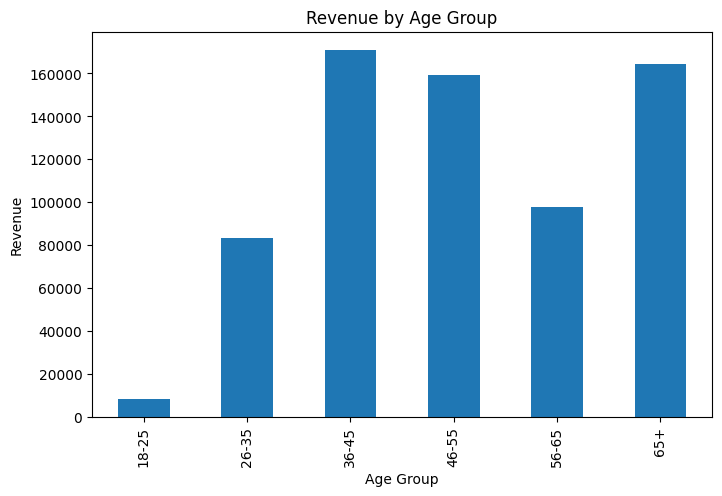

In [20]:
import matplotlib.pyplot as plt

revenue_by_age = df.groupby('age_group')['amt'].sum()

plt.figure(figsize=(8,5))
revenue_by_age.plot(kind='bar')

plt.title('Revenue by Age Group')
plt.ylabel('Revenue')
plt.xlabel('Age Group')

plt.show()

EXECUTIVE INSIGHTS

1. Total Transaction Value: $684,134.86
2. Total Transactions: 10,000
3. Average Transaction Value: $68.41
4. Fraud Rate: 0.47%

CUSTOMER INSIGHTS

1. Female customers contribute 54.3% of revenue.
2. Age group 36-45 generates highest revenue.
3. 18-25 segment contributes the least revenue.

MERCHANT INSIGHTS

1. Grocery category generates highest revenue.
2. Shopping and transportation categories are major contributors.

FRAUD INSIGHTS

1. Grocery POS and Shopping Net categories have highest fraud occurrences.
2. Overall fraud rate remains below 1%.

GEOGRAPHIC INSIGHTS

1. Pennsylvania generates highest transaction value.
2. Texas and New York are other major revenue regions.
